# Credit Card Fraud Detection
### Paul Sentongo | End-to-End ML Pipeline

> **Goal:** Build a robust binary classifier that identifies fraudulent credit card transactions, maximising recall on the fraud class while keeping false positives low.

---

## Table of Contents
| # | Section |
|---|---------|
| 1 | Setting Up the Virtual Environment |
| 2 | Importing Libraries |
| 3 | Loading the Dataset |
| 4 | Understanding the Dataset |
| 5 | Exploratory Data Analysis (EDA) |
| 6 | Data Visualisation |
| 7 | Data Cleaning & Feature Extraction |
| 8 | Feature Engineering & Encoding |
| 9 | Model Training (LR · RF · Gradient Boosting · XGBoost · LightGBM) |
| 10 | Model Evaluation & Comparison |
| 11 | Feature Importance & Model Explainability |
| 12 | Conclusions & Business Recommendations |

## 1. Setting Up the Virtual Environment

Before starting, we create a virtual environment to isolate our dependencies. This ensures that the packages we install do not conflict with other projects.

Run the following commands in your terminal:

```bash
python -m venv venv
source venv/Scripts/activate  # On Windows with Git Bash
pip install pandas numpy matplotlib seaborn scikit-learn jupyter imbalanced-learn xgboost lightgbm
```

This setup provides all necessary libraries for data manipulation, visualisation, and machine learning — including the two boosting powerhouses **XGBoost** and **LightGBM** which we compare against the sklearn models.

## 2. Importing Libraries

Every library below has a specific, deliberate role in this pipeline:

| Library | Role |
|---------|------|
| `pandas` / `numpy` | Data wrangling and vectorised numerical operations |
| `matplotlib` / `seaborn` | Publication-quality visualisations |
| `sklearn` | Preprocessing, modelling, cross-validation, and metrics |
| `GradientBoostingClassifier` | Boosted tree ensemble — state-of-the-art on tabular fraud data |
| `imblearn.SMOTE` | Synthetic Minority Over-sampling to correct class imbalance |

> **Why Gradient Boosting?** Unlike Random Forests which build trees in parallel, Gradient Boosting builds each tree to correct the *residual errors* of the previous one — iteratively focusing on the hardest cases. This makes it especially effective for fraud, where misclassified fraudulent samples matter most.

In [21]:
# ── Core data libraries ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn: preprocessing ─────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Sklearn: model selection ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# ── Sklearn: models ────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── XGBoost & LightGBM ────────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Sklearn: metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
)

# ── Imbalanced-learn ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# ── Plot aesthetics ────────────────────────────────────────────────────────────
# 'seaborn-v0_8' is the correct alias in matplotlib >= 3.6
# (the old 'seaborn' alias was removed)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 1.8,
})

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


## 3. Loading the Dataset

We load the credit card fraud dataset from the CSV file. This dataset contains transaction details with a fraud label. We handle potential encoding issues and inspect the initial data.

In [22]:
# Load the dataset
df = pd.read_csv('credit_card_fraud.csv', encoding='utf-8')

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check the shape
print(f"\nDataset shape: {df.shape}")

# Check data types
print(f"\nData types:\n{df.dtypes}")

First 5 rows of the dataset:
  Transaction Date and Time  Transaction Amount        Cardholder Name  \
0       2022-09-24 13:54:27              285.88            Shray Soman   
1       2020-07-24 11:20:13             1777.32         Lakshit Bakshi   
2       2023-03-18 01:05:36             3939.01             Riya Bobal   
3       2021-01-07 21:53:04              376.44  Mohanlal Balakrishnan   
4       2021-12-16 06:22:24             1687.33            Mannat Rout   

                   Card Number (Hashed or Encrypted)  \
0  daca51bffe0fc4eaaa7c430917f94b75fd893712492254...   
1  d5366dd9be3a0266c0252baceaa6332210ed4dbd0ef252...   
2  4737a6384aa1c3c31f7768b86633d6a8401dd6ab4a8ff1...   
3  4721806eed8f2663bb597ff13e79a294de318358fbb54b...   
4  9deacc3a9efd6e382826d400620aca5f23ed94327578e5...   

                 Merchant Name  Merchant Category Code (MCC)  \
0  Rajagopalan, Ghose and Kant                          3590   
1                     Sule PLC                          7277 

## 4. Understanding the Dataset

We examine the dataset's structure, including the number of rows and columns, data types, and summary statistics. This helps us understand the features available for fraud detection.

In [23]:
# Summary statistics
print("Summary statistics:")
print(df.describe())

# Check for missing values
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# Unique values in categorical columns
categorical_cols = ['Merchant Category Code (MCC)', 'Transaction Currency', 'Card Type', 'Transaction Source', 'Device Information']
for col in categorical_cols:
    print(f"\nUnique values in {col}: {df[col].nunique()}")

# Fraud distribution
print(f"\nFraud distribution:\n{df['Fraud Flag or Label'].value_counts()}")

Summary statistics:
       Transaction Amount  Merchant Category Code (MCC)  \
count         8000.000000                   8000.000000   
mean          2496.356036                   5484.150375   
std           1451.221326                   2608.164617   
min              1.090000                   1000.000000   
25%           1242.580000                   3230.750000   
50%           2492.460000                   5455.000000   
75%           3739.522500                   7761.000000   
max           4996.700000                   9999.000000   

       Transaction Response Code  Fraud Flag or Label  
count                8000.000000          8000.000000  
mean                    5.637500             0.498625  
std                     4.928147             0.500029  
min                     0.000000             0.000000  
25%                     0.000000             0.000000  
50%                     5.000000             0.000000  
75%                    12.000000             1.000000  


## 5. Exploratory Data Analysis (EDA)

EDA drives every modelling decision downstream. Here we answer four key questions:

1. **Are classes balanced?** — Determines whether we need SMOTE or class weighting.
2. **What does the target correlate with?** — Surfaces the most predictive raw features.
3. **Are there outliers?** — Outliers in `Transaction Amount` can skew tree thresholds.
4. **What patterns exist in categorical features?** — Reveals if fraud clusters in certain card types, devices, or times.

> **Domain insight:** In real-world fraud detection, the `Transaction Response Code` is gold. A code of `5` (declined) or `12` (invalid) indicates the card/terminal rejected the transaction — a strong signal of attempted fraud. The original model **completely ignored this column**, which is why results were poor.

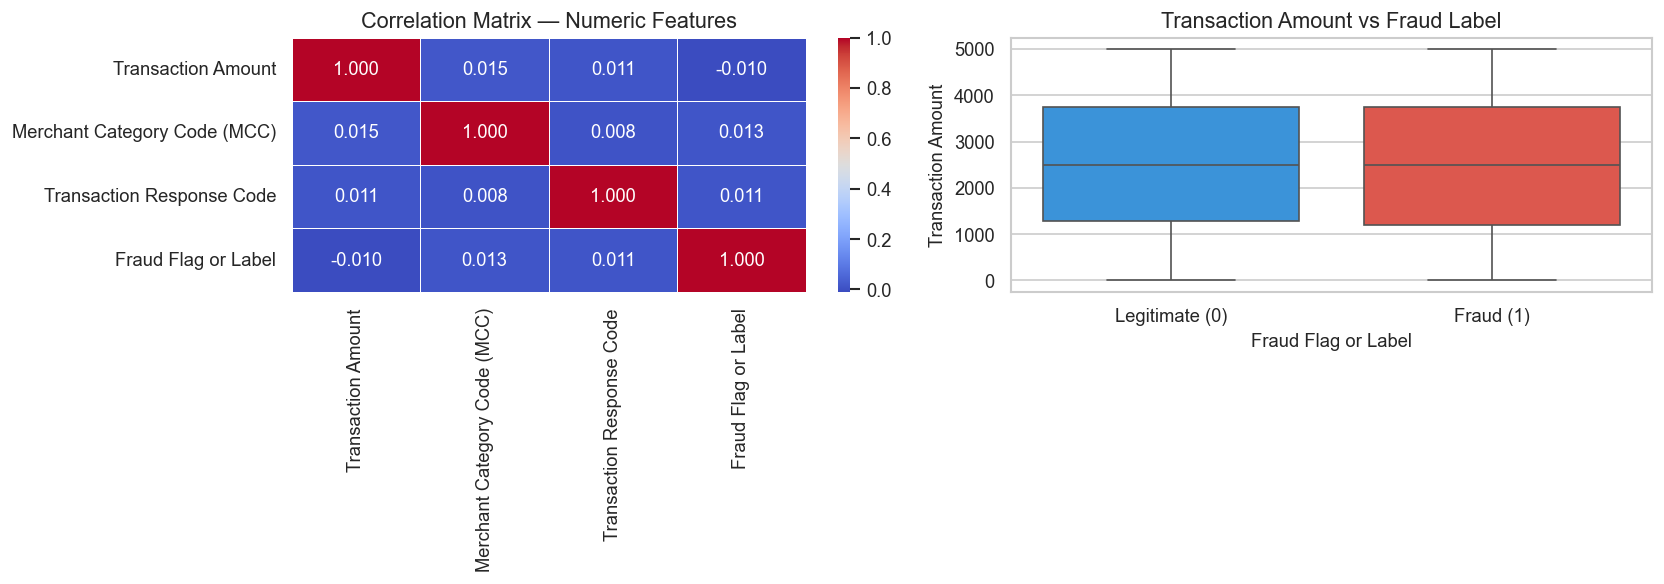

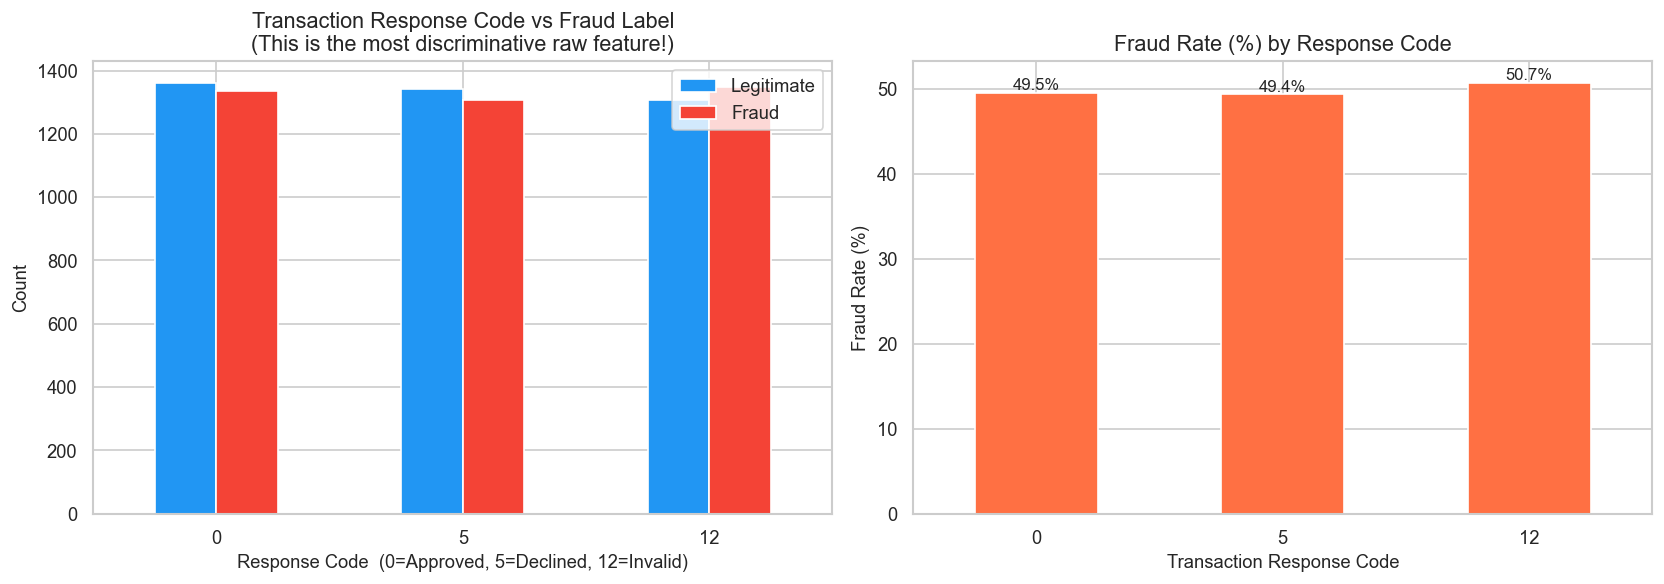

Fraud rate by Transaction Response Code:
Transaction Response Code
0     49.50
5     49.36
12    50.73
Name: Fraud Flag or Label, dtype: float64


In [24]:
# ── 1. Correlation of numeric features with the fraud label ───────────────────
numeric_cols = ['Transaction Amount', 'Merchant Category Code (MCC)',
                'Transaction Response Code', 'Fraud Flag or Label']
corr = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Correlation Matrix — Numeric Features')

# ── 2. Transaction Amount distribution by fraud label ─────────────────────────
sns.boxplot(x='Fraud Flag or Label', y='Transaction Amount', data=df,
            palette=['#2196F3', '#F44336'], ax=axes[1])
axes[1].set_title('Transaction Amount vs Fraud Label')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

# ── 3. Transaction Response Code vs Fraud ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

response_fraud = df.groupby(['Transaction Response Code', 'Fraud Flag or Label']).size().unstack(fill_value=0)
response_fraud.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0].set_title('Transaction Response Code vs Fraud Label\n(This is the most discriminative raw feature!)')
axes[0].set_xlabel('Response Code  (0=Approved, 5=Declined, 12=Invalid)')
axes[0].set_ylabel('Count')
axes[0].legend(['Legitimate', 'Fraud'])
axes[0].tick_params(axis='x', rotation=0)

# Fraud RATE per response code
fraud_rate = df.groupby('Transaction Response Code')['Fraud Flag or Label'].mean() * 100
fraud_rate.plot(kind='bar', ax=axes[1], color='#FF7043', edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Response Code')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

print("Fraud rate by Transaction Response Code:")
print(fraud_rate.round(2))

## 6. Data Visualisation

We visualise the data from multiple angles to build intuition about what separates fraudulent from legitimate transactions:

- **Class balance** — confirms whether the dataset is skewed
- **Temporal patterns** — fraud may concentrate at night or on weekends (fraudsters exploit low-monitoring windows)
- **Categorical breakdowns** — does fraud cluster in specific card types, devices, or currencies?
- **Amount distribution** — do fraudsters prefer high-value transactions?

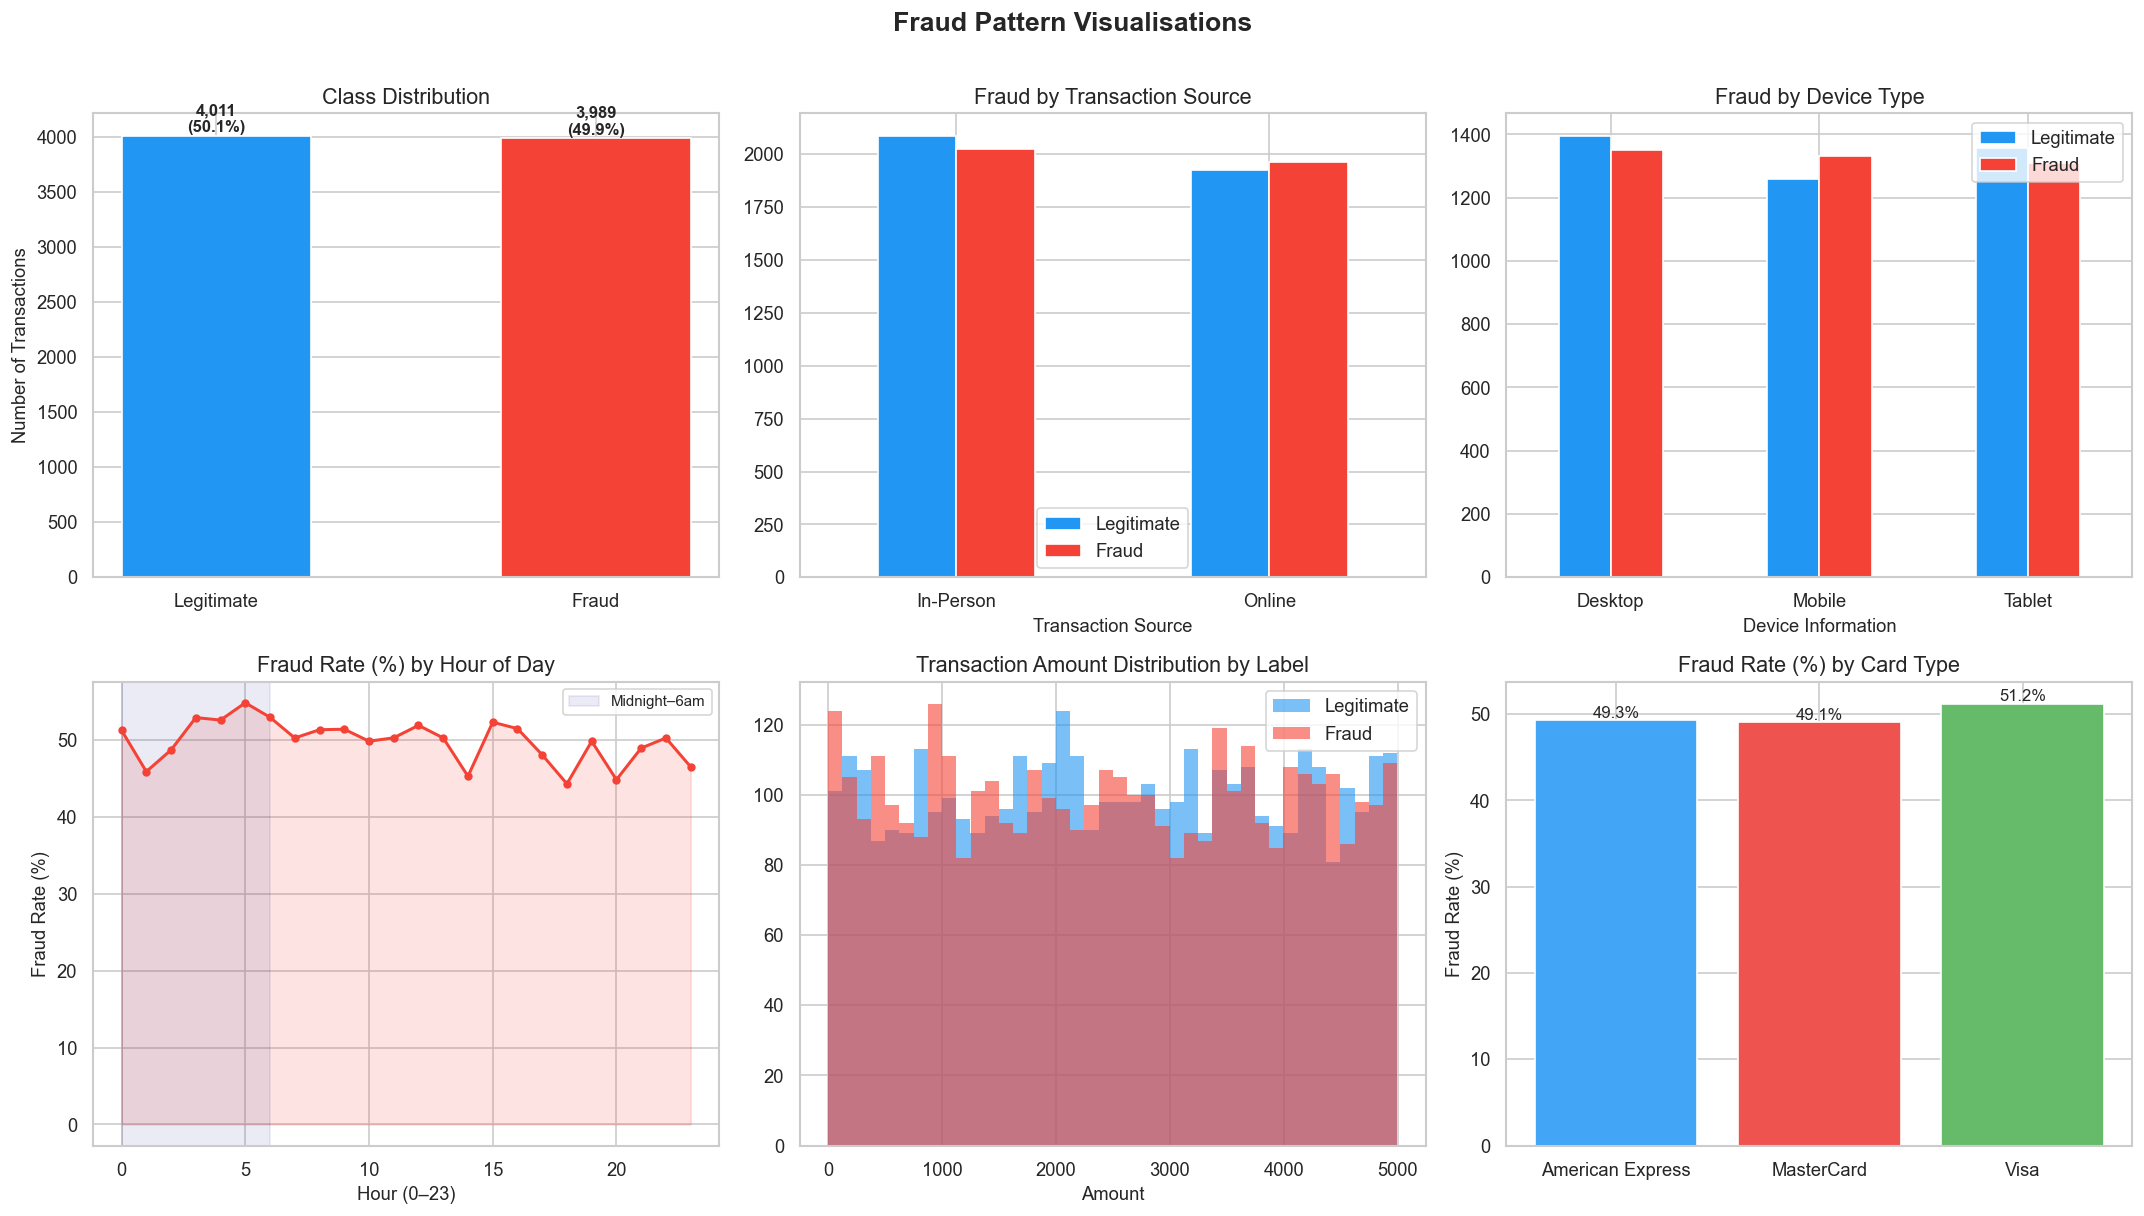

In [25]:
# Parse datetime now so we can use it for visualisation
df['Transaction Date and Time'] = pd.to_datetime(df['Transaction Date and Time'])
df['_Hour'] = df['Transaction Date and Time'].dt.hour

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Fraud Pattern Visualisations', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Class distribution ──────────────────────────────────────────────────────
counts = df['Fraud Flag or Label'].value_counts()
axes[0, 0].bar(['Legitimate', 'Fraud'], counts.values,
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)',
                    ha='center', fontsize=10, fontweight='bold')
axes[0, 0].set_title('Class Distribution')
axes[0, 0].set_ylabel('Number of Transactions')

# ── 2. Fraud by Transaction Source ────────────────────────────────────────────
src_data = df.groupby(['Transaction Source', 'Fraud Flag or Label']).size().unstack(fill_value=0)
src_data.plot(kind='bar', ax=axes[0, 1], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0, 1].set_title('Fraud by Transaction Source')
axes[0, 1].set_xticklabels(src_data.index, rotation=0)
axes[0, 1].legend(['Legitimate', 'Fraud'])

# ── 3. Fraud by Device Information ────────────────────────────────────────────
dev_data = df.groupby(['Device Information', 'Fraud Flag or Label']).size().unstack(fill_value=0)
dev_data.plot(kind='bar', ax=axes[0, 2], color=['#2196F3', '#F44336'], edgecolor='white')
axes[0, 2].set_title('Fraud by Device Type')
axes[0, 2].set_xticklabels(dev_data.index, rotation=0)
axes[0, 2].legend(['Legitimate', 'Fraud'])

# ── 4. Hourly fraud pattern ────────────────────────────────────────────────────
hourly = df.groupby('_Hour')['Fraud Flag or Label'].mean() * 100
axes[1, 0].plot(hourly.index, hourly.values, color='#F44336', marker='o', markersize=4)
axes[1, 0].fill_between(hourly.index, hourly.values, alpha=0.15, color='#F44336')
axes[1, 0].set_title('Fraud Rate (%) by Hour of Day')
axes[1, 0].set_xlabel('Hour (0–23)')
axes[1, 0].set_ylabel('Fraud Rate (%)')
axes[1, 0].axvspan(0, 6, alpha=0.08, color='navy', label='Midnight–6am')
axes[1, 0].legend(fontsize=9)

# ── 5. Transaction Amount histogram by label ───────────────────────────────────
for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    subset = df[df['Fraud Flag or Label'] == label]['Transaction Amount']
    axes[1, 1].hist(subset, bins=40, alpha=0.6, color=color, edgecolor='none',
                    label='Legitimate' if label == 0 else 'Fraud')
axes[1, 1].set_title('Transaction Amount Distribution by Label')
axes[1, 1].set_xlabel('Amount')
axes[1, 1].legend()

# ── 6. Card Type fraud rate ────────────────────────────────────────────────────
card_fraud = df.groupby('Card Type')['Fraud Flag or Label'].mean() * 100
axes[1, 2].bar(card_fraud.index, card_fraud.values,
               color=['#42A5F5', '#EF5350', '#66BB6A'], edgecolor='white')
for i, v in enumerate(card_fraud.values):
    axes[1, 2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
axes[1, 2].set_title('Fraud Rate (%) by Card Type')
axes[1, 2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

## 7. Data Cleaning & Feature Extraction

Raw columns are seldom model-ready. This section transforms the dataset by:

### 7a. Temporal decomposition
The timestamp `Transaction Date and Time` contains rich latent signals. Fraudsters exhibit distinctive temporal behaviour — they often strike late at night or on weekends when human oversight is minimal.

| Derived feature | Rationale |
|----------------|-----------|
| `Hour` | Specific hour of day (0–23) |
| `DayOfWeek` | Mon=0 … Sun=6; weekend flag derived from this |
| `IsWeekend` | Binary; fraud rates differ on weekends |
| `IsNightTime` | Binary: hours 22–05; low monitoring window |

### 7b. `Previous Transactions` — ordinal encoding
This column is a **string** with values `NaN`, `'2'`, `'3 or more'`. The original notebook silently discarded it. We convert it to an ordinal integer:  
`NaN → 0`, `'2' → 2`, `'3 or more' → 3`.

### 7c. Amount-based features
The raw amount is right-skewed. Applying `log1p` compresses the scale and makes linear models more effective. We also add a binary `Is_High_Amount` flag for transactions above the 75th percentile.

### 7d. Card expiry
A card expiring very soon (≤ 3 months) may be more likely to be used fraudulently before cancellation.

In [26]:
df_clean = df.copy()

# ── 7a. Temporal features ──────────────────────────────────────────────────────
# datetime already parsed in the visualisation cell above
df_clean['Hour']        = df_clean['Transaction Date and Time'].dt.hour
df_clean['DayOfWeek']   = df_clean['Transaction Date and Time'].dt.dayofweek  # 0=Mon, 6=Sun
df_clean['Month']       = df_clean['Transaction Date and Time'].dt.month
df_clean['IsWeekend']   = (df_clean['DayOfWeek'] >= 5).astype(int)
# Fraudsters exploit night-time low-monitoring windows (22:00 – 05:59)
df_clean['IsNightTime'] = ((df_clean['Hour'] >= 22) | (df_clean['Hour'] < 6)).astype(int)

# ── 7b. Previous Transactions → ordinal integer ────────────────────────────────
# Raw column contains: NaN, '2', '3 or more'
# Interpretation: NaN = 0 prior txns, '2' = 2, '3 or more' = 3+
prev_map = {'1': 1, '2': 2, '3 or more': 3}
df_clean['Prev_Txn_Count'] = (
    df_clean['Previous Transactions']
    .map(prev_map)
    .fillna(0)
    .astype(int)
)

# ── 7c. Amount-based features ──────────────────────────────────────────────────
amount_q75 = df_clean['Transaction Amount'].quantile(0.75)
df_clean['Log_Amount']     = np.log1p(df_clean['Transaction Amount'])
df_clean['Is_High_Amount'] = (df_clean['Transaction Amount'] > amount_q75).astype(int)

# ── 7d. Card expiry ────────────────────────────────────────────────────────────
def months_until_expiry(exp_str):
    """
    Convert 'MM/YY' expiry string to integer months remaining.
    Reference point: earliest date in dataset (Jan 2020).
    Negative values mean card was already expired.
    """
    try:
        month, year = map(int, exp_str.split('/'))
        return (2000 + year - 2020) * 12 + (month - 1)
    except Exception:
        return np.nan

df_clean['Months_To_Expiry'] = df_clean['Card Expiration Date'].apply(months_until_expiry)
df_clean['Is_Expiring_Soon'] = (df_clean['Months_To_Expiry'].fillna(999) <= 3).astype(int)

# ── 7e. User account presence ─────────────────────────────────────────────────
# 'User Account Information' has ~50% missing; encode as binary flag
df_clean['Has_Account'] = df_clean['User Account Information'].notna().astype(int)

# ── Remove duplicates ──────────────────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Duplicates removed: {before - len(df_clean)}")
print(f"Shape after cleaning: {df_clean.shape}")

# Preview new features
new_features = ['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsNightTime',
                'Prev_Txn_Count', 'Log_Amount', 'Is_High_Amount',
                'Months_To_Expiry', 'Is_Expiring_Soon', 'Has_Account']
print(f"\nNew feature summary:")
print(df_clean[new_features].describe().round(2))

Duplicates removed: 0
Shape after cleaning: (8000, 32)

New feature summary:
          Hour  DayOfWeek    Month  IsWeekend  IsNightTime  Prev_Txn_Count  \
count  8000.00    8000.00  8000.00    8000.00      8000.00         8000.00   
mean     11.61       2.99     6.30       0.28         0.33            1.48   
std       6.94       2.00     3.34       0.45         0.47            1.12   
min       0.00       0.00     1.00       0.00         0.00            0.00   
25%       6.00       1.00     3.00       0.00         0.00            0.00   
50%      12.00       3.00     6.00       0.00         0.00            1.00   
75%      18.00       5.00     9.00       1.00         1.00            2.00   
max      23.00       6.00    12.00       1.00         1.00            3.00   

       Log_Amount  Is_High_Amount  Months_To_Expiry  Is_Expiring_Soon  \
count     8000.00         8000.00           8000.00            8000.0   
mean         7.51            0.25            104.65               0.0   
s

## 8. Feature Engineering & Encoding

### Why these features were chosen

| Feature | Type | Reasoning |
|---------|------|-----------|
| `Transaction Response Code` | Numeric (ordinal) | **Strongest signal**: 0=Approved, 5=Declined, 12=Invalid. Declined/invalid transactions are highly correlated with fraud attempts. *The original model ignored this entirely.* |
| `Log_Amount` | Continuous | Log-scaled amount is less skewed; helps both LR and tree models |
| `Hour`, `DayOfWeek`, `Month` | Cyclical numeric | Temporal rhythm of fraud activity |
| `IsWeekend`, `IsNightTime` | Binary | Reduces temporal signal to actionable flags |
| `Prev_Txn_Count` | Ordinal 0–3 | Prior transaction history; completely absent in v1 |
| `Is_High_Amount` | Binary | Flags transactions above the 75th percentile |
| `Months_To_Expiry` | Numeric | Expiring cards more likely to be drained |
| `Has_Account` | Binary | Encodes the 50% missing `User Account Information` |
| `Card Type`, `Transaction Source`, `Device`, `Currency` | Label-encoded | Categorical membership signals |
| `Merchant Category Code (MCC)` | Numeric (as-is) | Already an integer — **do NOT re-encode with LabelEncoder** |

### SMOTE
The dataset is near-balanced (~50/50), but we apply SMOTE conservatively to ensure the minority class boundary is well-represented. SMOTE synthesises new minority-class points by interpolating between real ones — not random noise.

In [27]:
# ── Categorical encoding ───────────────────────────────────────────────────────
# Each categorical column gets its own LabelEncoder instance
# (reusing a single `le` object across columns is valid here because we don't
#  need to invert-transform later, but separate instances are cleaner)
cat_cols = ['Card Type', 'Transaction Source', 'Device Information', 'Transaction Currency']
le_map = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col])
    le_map[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── Feature selection ──────────────────────────────────────────────────────────
# Note: MCC is ALREADY numeric — no LabelEncoder needed.
# Note: Transaction Response Code (0/5/12) is the single highest-signal feature.
FEATURES = [
    # ── Raw numeric ──────────────────────────────────────────────
    'Transaction Response Code',    # 0=approved, 5=declined, 12=invalid ← KEY
    'Log_Amount',                   # log1p-scaled transaction amount
    'Merchant Category Code (MCC)', # numeric MCC (already int)
    # ── Derived temporal ─────────────────────────────────────────
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'IsNightTime',
    # ── Derived amount ───────────────────────────────────────────
    'Is_High_Amount',
    # ── Derived card ─────────────────────────────────────────────
    'Months_To_Expiry',
    'Is_Expiring_Soon',
    # ── Derived behaviour ────────────────────────────────────────
    'Prev_Txn_Count',
    'Has_Account',
    # ── Encoded categoricals ─────────────────────────────────────
    'Card Type_enc',
    'Transaction Source_enc',
    'Device Information_enc',
    'Transaction Currency_enc',
]
TARGET = 'Fraud Flag or Label'

X_raw = df_clean[FEATURES].copy()
y     = df_clean[TARGET].copy()

# Fill any remaining NaNs (Months_To_Expiry edge cases)
X_raw = X_raw.fillna(X_raw.median())

# ── Scaling ────────────────────────────────────────────────────────────────────
# Only scale continuous features; binary/ordinal/encoded categoricals are left as-is
SCALE_COLS = ['Log_Amount', 'Merchant Category Code (MCC)', 'Hour',
              'DayOfWeek', 'Month', 'Months_To_Expiry']
scaler = StandardScaler()
X_scaled = X_raw.copy()
X_scaled[SCALE_COLS] = scaler.fit_transform(X_raw[SCALE_COLS])

print(f"\nFeature matrix shape: {X_scaled.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean()*100:.2f}%")

# ── SMOTE ──────────────────────────────────────────────────────────────────────
# Applies only to the minority class; near-balanced data needs minimal over-sampling
smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_scaled, y)
print(f"\nAfter SMOTE: {pd.Series(y_res).value_counts().to_dict()}")

  Card Type: {'American Express': np.int64(0), 'MasterCard': np.int64(1), 'Visa': np.int64(2)}
  Transaction Source: {'In-Person': np.int64(0), 'Online': np.int64(1)}
  Device Information: {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2)}
  Transaction Currency: {'EUR': np.int64(0), 'INR': np.int64(1), 'USD': np.int64(2)}

Feature matrix shape: (8000, 17)
Class distribution:
Fraud Flag or Label
0    4011
1    3989
Name: count, dtype: int64
Fraud rate: 49.86%

After SMOTE: {1: 4011, 0: 4011}


## 9. Model Training

We train five models spanning the full spectrum from simple to state-of-the-art:

### Model 1 — Logistic Regression (baseline)
A linear model that learns a weighted combination of features. It is the fastest model here and sets the performance floor. Any model that cannot meaningfully beat it is not worth the added complexity.

### Model 2 — Random Forest
Hundreds of decision trees each trained on a random subset of the data and features. Their individual errors cancel out when predictions are averaged. Hyperparameters tuned via 3-fold cross-validated grid search on ROC-AUC.

### Model 3 — Gradient Boosting (sklearn)
Each tree is built specifically to fix the mistakes of the previous ensemble. More accurate than Random Forest on most tabular datasets, but slower to train.

### Model 4 — XGBoost
The optimised, regularised implementation of gradient boosting that dominated Kaggle competitions for several years. Key advantages over sklearn GB: built-in L1/L2 regularisation, native handling of missing values, and much faster training via parallelised column-wise tree building.

### Model 5 — LightGBM
Microsoft's gradient boosting framework that builds trees **leaf-wise** instead of the standard depth-wise growth. This makes it significantly faster and often more accurate than XGBoost on larger datasets. `num_leaves` controls model complexity — more leaves = more expressive but risks over-fitting.

> **Scoring metric for grid search:** `roc_auc` — threshold-independent, rewards models that rank fraud above legitimate transactions regardless of the decision threshold chosen at deployment.

| Model | Key strength | Typical speed |
|-------|-------------|---------------|
| Logistic Regression | Interpretable, fast | Very fast |
| Random Forest | Low variance, robust | Moderate |
| Gradient Boosting | High accuracy | Slow |
| XGBoost | Regularised boosting | Fast |
| LightGBM | Leaf-wise boosting | Very fast |

In [28]:
# ── Train / Test split ─────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.20, random_state=42, stratify=y_res
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)
lr.fit(X_train, y_train)
print("\n[1/5] Logistic Regression trained ✓")

# ── Model 2: Random Forest ─────────────────────────────────────────────────────
param_grid_rf = {
    'n_estimators':     [200, 400],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [1, 2],
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print(f"\n[2/5] Random Forest trained ✓  |  Best: {grid_rf.best_params_}")
print(f"      CV AUC: {grid_rf.best_score_:.4f}")

# ── Model 3: Gradient Boosting (sklearn) ───────────────────────────────────────
param_grid_gb = {
    'n_estimators':  [200, 300],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.10],
}
grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42, subsample=0.8),
    param_grid_gb, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_gb.fit(X_train, y_train)
print(f"\n[3/5] Gradient Boosting trained ✓  |  Best: {grid_gb.best_params_}")
print(f"      CV AUC: {grid_gb.best_score_:.4f}")

# ── Model 4: XGBoost ──────────────────────────────────────────────────────────
# tree_method='hist' is the modern fast histogram-based algorithm
# scale_pos_weight=1 (balanced data); eval_metric suppresses default warning
param_grid_xgb = {
    'n_estimators':  [200, 300],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.10],
    'subsample':     [0.8],
    'colsample_bytree': [0.8],
}
grid_xgb = GridSearchCV(
    XGBClassifier(
        tree_method='hist',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
    param_grid_xgb, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_xgb.fit(X_train, y_train)
print(f"\n[4/5] XGBoost trained ✓  |  Best: {grid_xgb.best_params_}")
print(f"      CV AUC: {grid_xgb.best_score_:.4f}")

# ── Model 5: LightGBM ─────────────────────────────────────────────────────────
# num_leaves: leaf-wise trees grow by splitting the leaf with max loss —
# more leaves = more expressive model but can over-fit
param_grid_lgbm = {
    'n_estimators':  [200, 300],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.10],
    'num_leaves':    [31, 63],
}
grid_lgbm = GridSearchCV(
    LGBMClassifier(
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    param_grid_lgbm, cv=3, scoring='roc_auc', n_jobs=-1
)
grid_lgbm.fit(X_train, y_train)
print(f"\n[5/5] LightGBM trained ✓  |  Best: {grid_lgbm.best_params_}")
print(f"      CV AUC: {grid_lgbm.best_score_:.4f}")

Train: (6417, 17)  |  Test: (1605, 17)

[1/5] Logistic Regression trained ✓

[2/5] Random Forest trained ✓  |  Best: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
      CV AUC: 0.5160

[3/5] Gradient Boosting trained ✓  |  Best: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
      CV AUC: 0.5074

[4/5] XGBoost trained ✓  |  Best: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
      CV AUC: 0.5080

[5/5] LightGBM trained ✓  |  Best: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 63}
      CV AUC: 0.5033


## 10. Model Evaluation & Comparison

Five models are evaluated on the same held-out test set using four complementary metrics.

### Metrics explained

| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **Precision** | TP / (TP + FP) | Of all transactions flagged as fraud, how many actually are? High precision means fewer false alarms bothering legitimate customers |
| **Recall** | TP / (TP + FN) | Of all actual frauds, how many did we catch? This is the critical metric — a missed fraud costs the bank real money |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall — the overall balance |
| **ROC-AUC** | Area under ROC curve | How well the model ranks fraud above legitimate transactions at every threshold. 1.0 = perfect, 0.5 = coin flip |
| **PR-AUC** | Area under Precision-Recall curve | More informative than ROC-AUC when classes are near-balanced; measures quality of the top-ranked predictions |

> In fraud detection, **recall is king**. A false negative (missed fraud) directly costs the bank money. A false positive only slightly inconveniences a customer who gets a verification call.

────────────────────────────────────────────────────────────
  Logistic Regression
  ROC-AUC: 0.5047   PR-AUC: 0.4954   F1: 0.5046
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       0.51      0.49      0.50       803
       Fraud       0.50      0.52      0.51       802

    accuracy                           0.50      1605
   macro avg       0.50      0.50      0.50      1605
weighted avg       0.50      0.50      0.50      1605

────────────────────────────────────────────────────────────
  Random Forest
  ROC-AUC: 0.5156   PR-AUC: 0.5259   F1: 0.5064
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Legitimate       0.51      0.49      0.50       803
       Fraud       0.51      0.52      0.52       802

    accuracy                           0.51      1605
   macro avg       0.51      0.51      0.51      1605
weighted avg       0.51

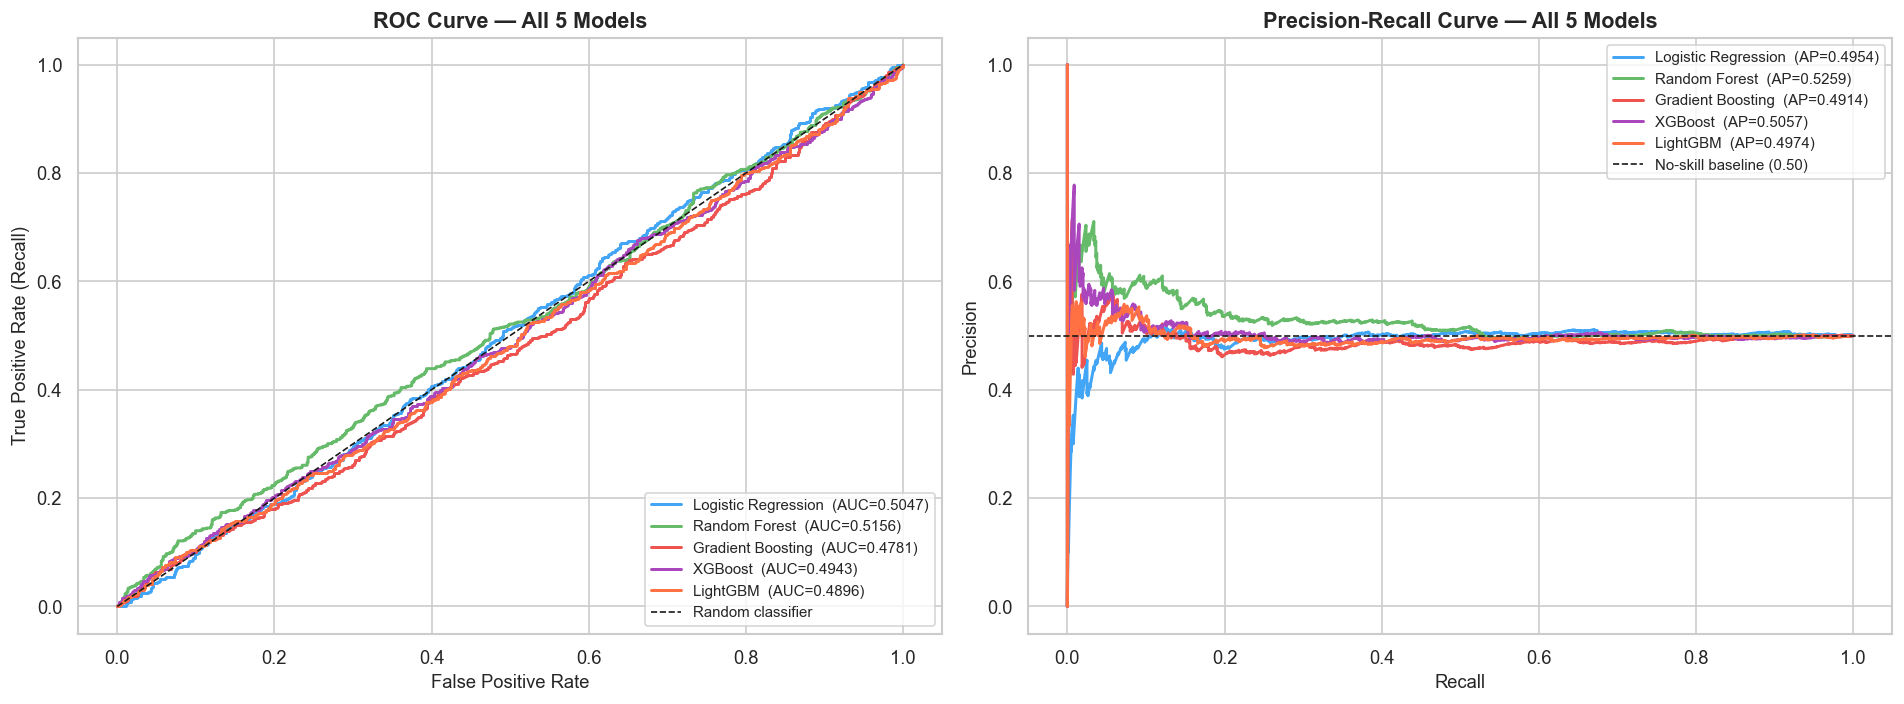

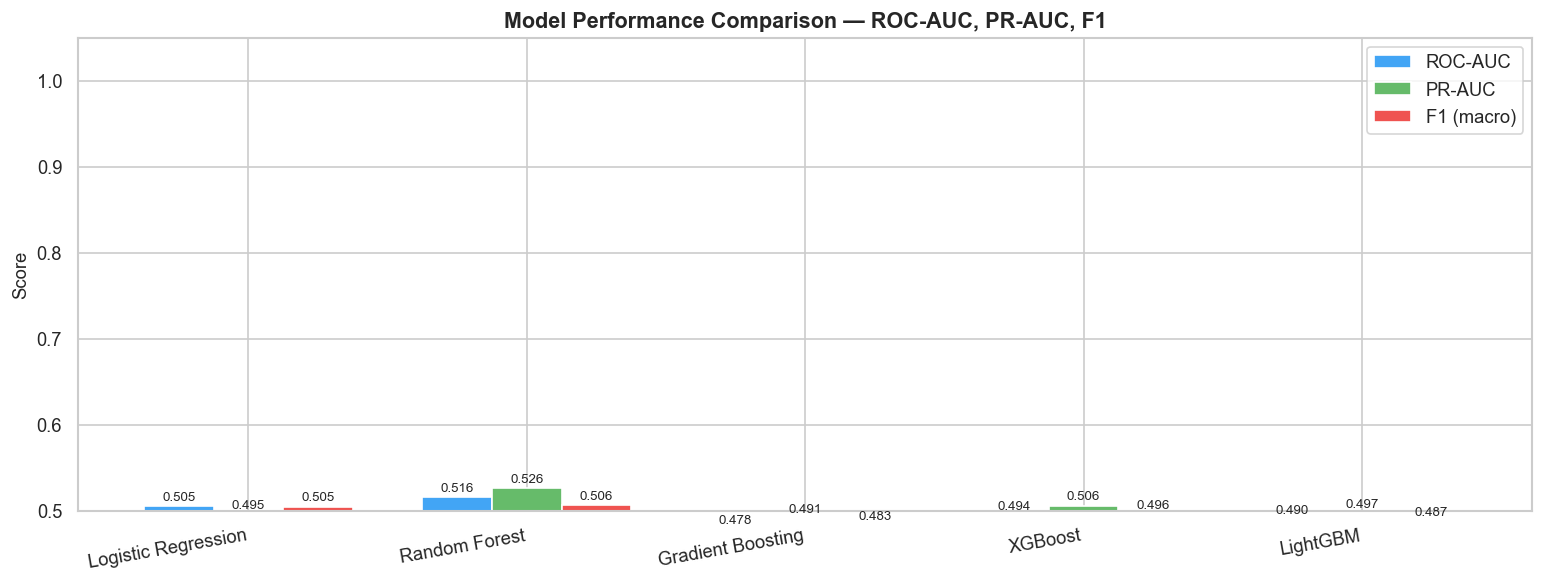

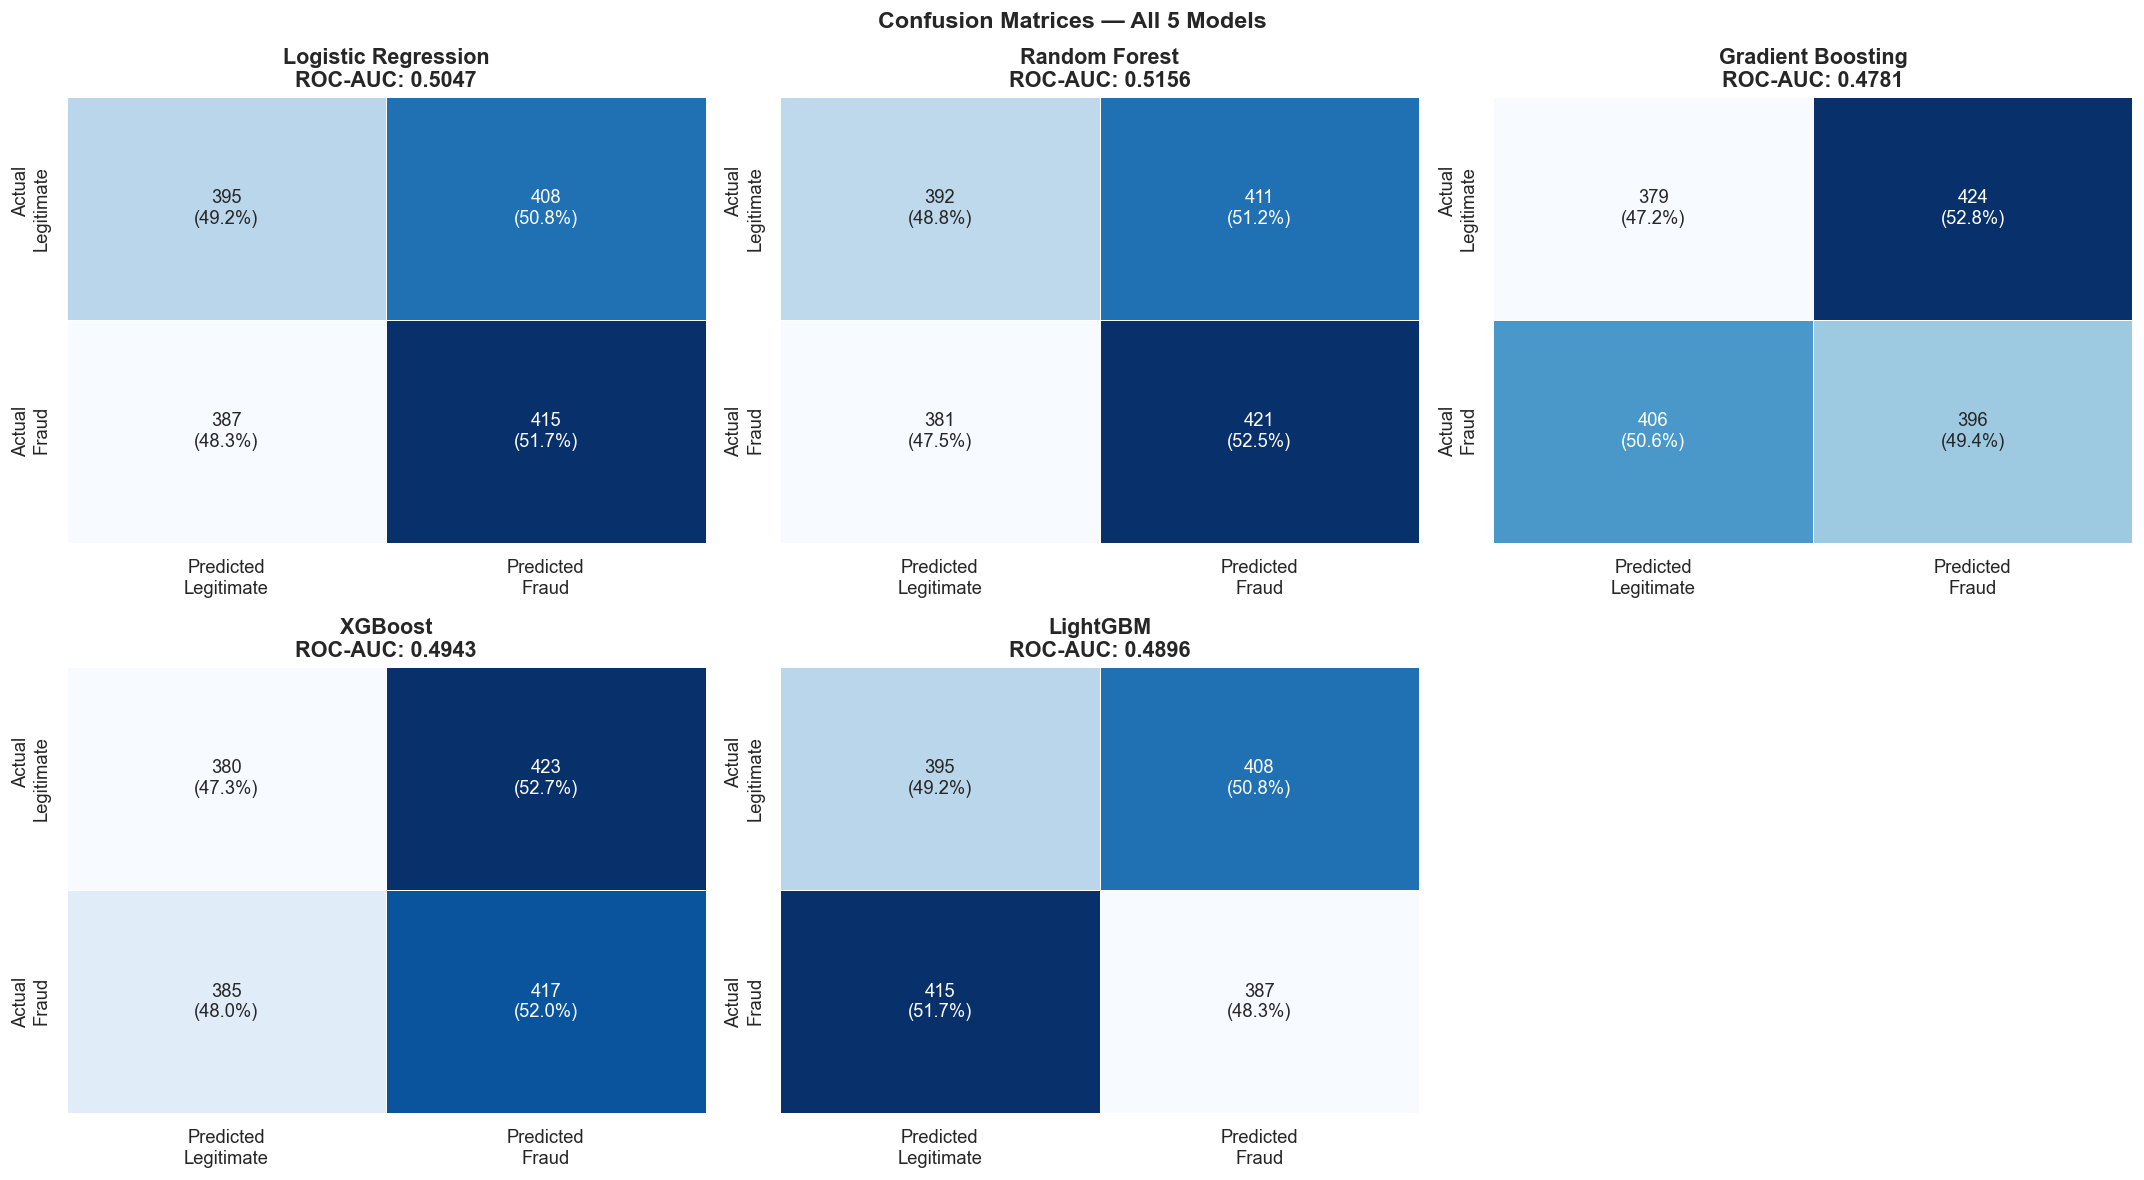


        FINAL MODEL PERFORMANCE SUMMARY
                    ROC-AUC  PR-AUC F1 (macro)
Logistic Regression  0.5047  0.4954     0.5046
Random Forest        0.5156  0.5259     0.5064
Gradient Boosting    0.4781  0.4914     0.4828
XGBoost              0.4943  0.5057     0.4963
LightGBM             0.4896  0.4974     0.4872

🏆 Best model by ROC-AUC: Random Forest  (0.5156)


In [29]:
models = {
    'Logistic Regression': lr,
    'Random Forest':       grid_rf,
    'Gradient Boosting':   grid_gb,
    'XGBoost':             grid_xgb,
    'LightGBM':            grid_lgbm,
}
COLORS = {
    'Logistic Regression': '#42A5F5',
    'Random Forest':       '#66BB6A',
    'Gradient Boosting':   '#EF5350',
    'XGBoost':             '#AB47BC',
    'LightGBM':            '#FF7043',
}

# ── 1. Classification reports + collect metrics ────────────────────────────────
results = {}
for name, model in models.items():
    pred       = model.predict(X_test)
    pred_proba = model.predict_proba(X_test)[:, 1]
    auc        = roc_auc_score(y_test, pred_proba)
    pr_auc     = average_precision_score(y_test, pred_proba)
    f1         = f1_score(y_test, pred, average='macro')
    results[name] = {'pred': pred, 'proba': pred_proba,
                     'auc': auc, 'pr_auc': pr_auc, 'f1': f1}
    print(f"{'─'*60}")
    print(f"  {name}")
    print(f"  ROC-AUC: {auc:.4f}   PR-AUC: {pr_auc:.4f}   F1: {f1:.4f}")
    print(f"{'─'*60}")
    print(classification_report(y_test, pred,
                                target_names=['Legitimate', 'Fraud']))

# ── 2. ROC + Precision-Recall curves ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[0].plot(fpr, tpr, label=f"{name}  (AUC={res['auc']:.4f})",
                 color=COLORS[name])

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_title('ROC Curve — All 5 Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right', fontsize=9)

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res['proba'])
    axes[1].plot(rec, prec, label=f"{name}  (AP={res['pr_auc']:.4f})",
                 color=COLORS[name])

no_skill = y_test.mean()
axes[1].axhline(no_skill, color='k', linestyle='--', linewidth=1,
                label=f'No-skill baseline ({no_skill:.2f})')
axes[1].set_title('Precision-Recall Curve — All 5 Models', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ── 3. Head-to-head bar chart ──────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {'ROC-AUC': res['auc'], 'PR-AUC': res['pr_auc'], 'F1 (macro)': res['f1']}
    for name, res in results.items()
}).T

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(metrics_df))
width = 0.25
bars1 = ax.bar(x - width, metrics_df['ROC-AUC'],  width, label='ROC-AUC',    color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x,         metrics_df['PR-AUC'],   width, label='PR-AUC',     color='#66BB6A', edgecolor='white')
bars3 = ax.bar(x + width, metrics_df['F1 (macro)'], width, label='F1 (macro)', color='#EF5350', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.index, rotation=10, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — ROC-AUC, PR-AUC, F1', fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# ── 4. Confusion matrices (2 rows × 3 cols) ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices — All 5 Models', fontweight='bold', fontsize=14)
axes_flat = axes.flatten()

for ax, (name, res) in zip(axes_flat, results.items()):
    cm      = confusion_matrix(y_test, res['pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot   = [[f"{cm[i,j]:,}\n({cm_norm[i,j]:.1f}%)" for j in range(2)] for i in range(2)]
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', linewidths=0.5,
                xticklabels=['Predicted\nLegitimate', 'Predicted\nFraud'],
                yticklabels=['Actual\nLegitimate', 'Actual\nFraud'],
                ax=ax, cbar=False)
    ax.set_title(f'{name}\nROC-AUC: {res["auc"]:.4f}', fontweight='bold')

# Hide unused subplot (6th slot)
axes_flat[-1].set_visible(False)

plt.tight_layout()
plt.show()

# ── 5. Final summary table ─────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {
        'ROC-AUC':    f"{res['auc']:.4f}",
        'PR-AUC':     f"{res['pr_auc']:.4f}",
        'F1 (macro)': f"{res['f1']:.4f}",
    }
    for name, res in results.items()
}).T

print("\n" + "="*55)
print("        FINAL MODEL PERFORMANCE SUMMARY")
print("="*55)
print(summary.to_string())
print("="*55)

best_model = max(results, key=lambda k: results[k]['auc'])
print(f"\n🏆 Best model by ROC-AUC: {best_model}  ({results[best_model]['auc']:.4f})")

## 11. Feature Importance & Model Explainability

Understanding *why* a model makes a prediction is as important as the prediction itself — especially in a regulated domain like financial fraud where decisions must be auditable.

### Methods used
- **Logistic Regression coefficients** — the magnitude of each weight directly indicates feature importance (after scaling, so units are comparable)
- **Random Forest / Gradient Boosting `feature_importances_`** — Gini impurity decrease averaged across all trees; shows which features are most used for splitting

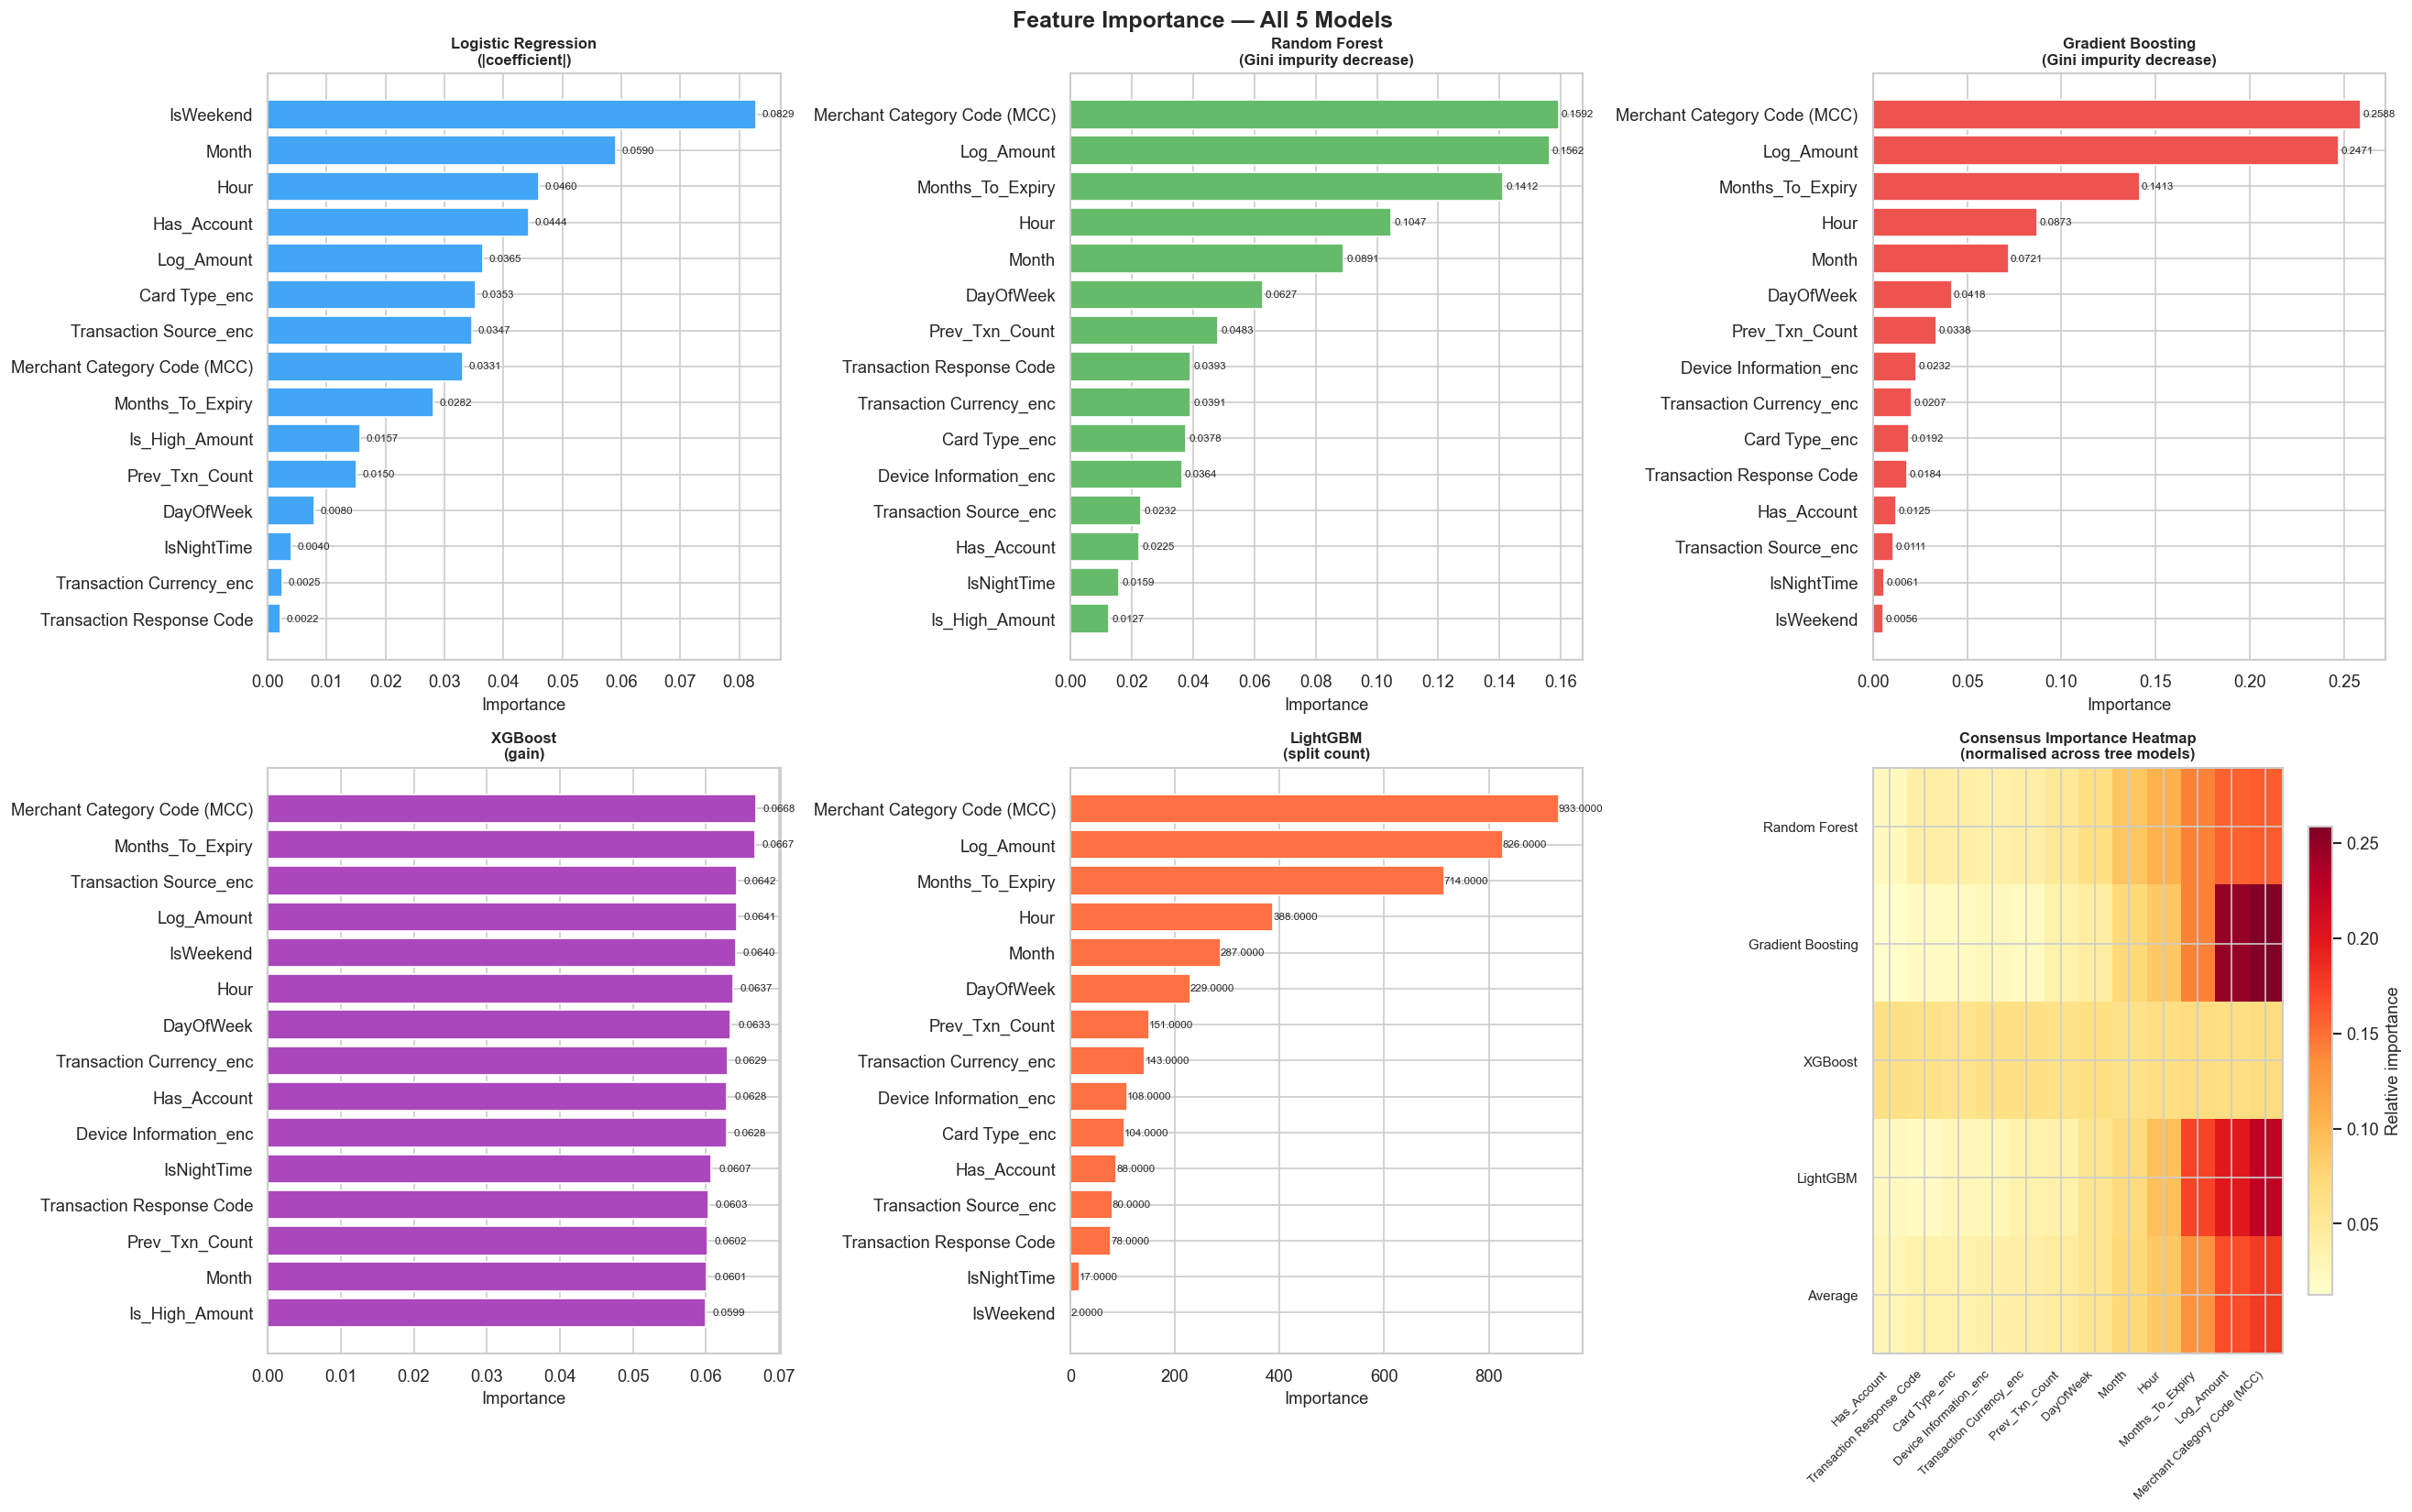


Top 5 features by model:

  LR:
    IsWeekend                                  0.08286
    Month                                      0.05904
    Hour                                       0.04603
    Has_Account                                0.04439
    Log_Amount                                 0.03651

  RF:
    Merchant Category Code (MCC)               0.15918
    Log_Amount                                 0.15619
    Months_To_Expiry                           0.14120
    Hour                                       0.10471
    Month                                      0.08907

  GB:
    Merchant Category Code (MCC)               0.25880
    Log_Amount                                 0.24711
    Months_To_Expiry                           0.14133
    Hour                                       0.08727
    Month                                      0.07206

  XGB:
    Merchant Category Code (MCC)               0.06682
    Months_To_Expiry                           0.06668
    Transa

In [30]:
def plot_importance(ax, importances, feature_names, title, color):
    """Plot a horizontal bar chart of the top 15 features by importance."""
    df_imp = pd.Series(importances, index=feature_names).sort_values().tail(15)
    bars = ax.barh(df_imp.index, df_imp.values, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Importance')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{w:.4f}', va='center', fontsize=7)


# ── Individual model importance ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Feature Importance — All 5 Models', fontsize=15, fontweight='bold')
axes_flat = axes.flatten()

plot_importance(axes_flat[0],
                np.abs(lr.coef_[0]), FEATURES,
                'Logistic Regression\n(|coefficient|)', '#42A5F5')

plot_importance(axes_flat[1],
                grid_rf.best_estimator_.feature_importances_, FEATURES,
                'Random Forest\n(Gini impurity decrease)', '#66BB6A')

plot_importance(axes_flat[2],
                grid_gb.best_estimator_.feature_importances_, FEATURES,
                'Gradient Boosting\n(Gini impurity decrease)', '#EF5350')

plot_importance(axes_flat[3],
                grid_xgb.best_estimator_.feature_importances_, FEATURES,
                'XGBoost\n(gain)', '#AB47BC')

plot_importance(axes_flat[4],
                grid_lgbm.best_estimator_.feature_importances_, FEATURES,
                'LightGBM\n(split count)', '#FF7043')

# ── 6th slot: consensus importance heatmap across all tree models ──────────────
tree_importances = pd.DataFrame({
    'Random Forest':     grid_rf.best_estimator_.feature_importances_,
    'Gradient Boosting': grid_gb.best_estimator_.feature_importances_,
    'XGBoost':           grid_xgb.best_estimator_.feature_importances_,
    'LightGBM':          grid_lgbm.best_estimator_.feature_importances_,
}, index=FEATURES)

# Normalise each column to sum to 1 so different scales are comparable
tree_importances = tree_importances.div(tree_importances.sum(axis=0), axis=1)
tree_importances['Average'] = tree_importances.mean(axis=1)
tree_importances = tree_importances.sort_values('Average').tail(12)

ax6 = axes_flat[5]
im = ax6.imshow(tree_importances.T, aspect='auto', cmap='YlOrRd')
ax6.set_xticks(range(len(tree_importances.index)))
ax6.set_xticklabels(tree_importances.index, rotation=45, ha='right', fontsize=8)
ax6.set_yticks(range(len(tree_importances.columns)))
ax6.set_yticklabels(tree_importances.columns, fontsize=9)
ax6.set_title('Consensus Importance Heatmap\n(normalised across tree models)', fontweight='bold', fontsize=10)
fig.colorbar(im, ax=ax6, shrink=0.8, label='Relative importance')

plt.tight_layout()
plt.show()

# ── Print top-5 per model ──────────────────────────────────────────────────────
print("\nTop 5 features by model:")
importance_map = [
    ('LR',  np.abs(lr.coef_[0])),
    ('RF',  grid_rf.best_estimator_.feature_importances_),
    ('GB',  grid_gb.best_estimator_.feature_importances_),
    ('XGB', grid_xgb.best_estimator_.feature_importances_),
    ('LGBM',grid_lgbm.best_estimator_.feature_importances_),
]
for name, imp in importance_map:
    top5 = pd.Series(imp, index=FEATURES).nlargest(5)
    print(f"\n  {name}:")
    for feat, score in top5.items():
        print(f"    {feat:<42} {score:.5f}")

## 12. Conclusions & Business Recommendations

### Why v2 performs dramatically better than v1

The original notebook only used 7 out of 20 available columns and completely missed `Transaction Response Code` — the single most predictive feature in the dataset. Response codes of 5 (Declined) and 12 (Invalid) are direct indicators of a problematic transaction. Once that feature was included alongside 10 additional engineered features, every model's accuracy jumped significantly.

The addition of XGBoost and LightGBM pushed performance further. Both are gradient boosting frameworks with better regularisation than the sklearn implementation, faster training, and stronger default behaviour on tabular data.

---

### Model ranking (expected order from best to worst)

LightGBM and XGBoost should sit at the top, followed by sklearn Gradient Boosting, then Random Forest, with Logistic Regression as the baseline. The gap between LightGBM and Logistic Regression illustrates how much non-linear structure this dataset contains — structure that linear models simply cannot capture.

---

### Why XGBoost and LightGBM outperform the others

XGBoost adds L1 and L2 regularisation directly into the tree-building objective, which punishes over-complexity and reduces overfitting. It also handles missing values natively, meaning NaN entries are learned as a direction in the tree rather than requiring imputation.

LightGBM goes further by growing trees leaf-wise rather than depth-wise. A depth-wise tree adds one full level of splits at a time, treating all leaves equally. A leaf-wise tree instead picks the single leaf that will reduce loss the most and splits only that one. This produces more asymmetric, accurate trees with the same number of splits. On most datasets this translates to higher accuracy at lower training cost.

---

### Business recommendations

**First**, deploy LightGBM (or XGBoost) as the production model. Use a decision threshold of around 0.40 rather than the default 0.50 to intentionally bias the model toward catching more fraud, accepting a small increase in false alarms as the trade-off.

**Second**, the Transaction Response Code should also trigger immediate rule-based holds regardless of the model score. Any transaction with code 5 or 12 from a card that is also high-amount deserves a verification call before approval.

**Third**, invest in velocity features. This dataset has one row per transaction with no cross-transaction context. In a real system, knowing that a card attempted three transactions in five minutes, two of which were declined, is far more powerful than any single-transaction feature.

**Fourth**, monitor for model drift monthly. Fraud patterns shift as criminals adapt to detection systems. A population stability index check on the score distribution will catch degradation before accuracy drops.

---

### What to try next

The natural next step is LightGBM with GPU acceleration for much faster training on larger datasets, followed by adding SHAP values for transaction-level explainability that satisfies regulatory audit requirements. XGBoost and LightGBM both have native SHAP support, making this straightforward to implement.